# Assignemnt2 
## 40 different house electricity consumption
There are two datasets **Main_data** and corresponding **Weather_data** 

### What the datasets represent

A synthetic smart-grid panel time series:
40 buildings (meter_id = M001…M040)

Hourly readings for 500 hours starting 2025-01-01 00:00

Total rows: 40 × 500 = 20,000

-------------------
### Main_data
Each row in **Main_data** file is one meter at one hour, with building attributes + pricing + behavior driving energy consumption.

Column groups (what’s inside)
1) Identifiers & time meter_id, timestamp
hour

2) Building “static” attributes (vary by meter)
building_type (residential/commercial/industrial)
region
floor_area_m2
insulation_rating (scaled from 0 to 1)
hvac_age_years (scaled from 0 to 20.2 years)
solar_kw_installed (scaled from 0 to 6.5 kw)
ev_charger (0/1)

3) grid conditions (vary by hour and region)

grid_price_usd_per_kwh
price depends on tariff tier and “temperature stress.”

4) Behavior & generation
   
occupancy_index (0–1 synthetic activity proxy)
solar_generation_kwh (daytime profile, reduced when precip > 0)

5) targeted variable
consumption_kwh (net kWh after solar)
----------------
### Weather_data
Weather data related to each meter_id is available in **Weather_data.CSV** file
Columns inside 
temp_c, humidity_pct, wind_ms, precip_mm
Weather has a diurnal cycle and region baselines; 
Weathers has a diurnal cycle and region baselines; price depends on tariff tier and “temperature stress.”


---------------------
# Please do the following tasks
1) Read the datasets and check the info, type of data, and so on.
2) Generate calendar features such as hour, day_of_week, is_weekend, and is_holiday? **Tips**:  Check the type of 'timestamp'column.
3) Generate per‑meter lag features such as lag1,lag24 over the consumption column. **Tips**: groupby method matters for each meter_id.
4) Generate per‑meter rolling features such as 24-hour consumption average and std.
5) Generate one main dataset with the index of timeseries data and concatenated with the corresponding weather dataset.
   
   --------------------
**From now on, it is very subjective and depends on the usecase you choose. It is up to you to test and check your learning by answering the following questions with different tools and tests.**

6) Choose one arbitrary meter_id related to residential building type and start presenting descriptive statistics over interesting columns such as consumption, weather data, and so on.
7) Please use different plot types visualization tools in seaborn or other Python packages to present more statistical information related to the selected meter_id over targeted column energy consumption or other interesting predictors such as weather data, solar generation, and so on.
8) Study the relation of the user_behavior information, such as weekend, is_holiday, with respect to the targeted variable, energy consumption.
9) How did your targeted variable respond to different energy prices and Tarif_tier?
10) Check that your data are stationary. Is there seasonality or a periodic component in your data? **Tips:** You can just do these analyses over the targeted variable. 
11)  Decompose the main component if there are periodic and nonstationary.
12)  Stationerise your data if it is needed.
----------------------------------------------------------
If you have time, choose another meter_id related to a commercial building and do the tasks from 6 to 10, and compare your findings with the residential one. 

In [17]:
# 1) Read the datasets and check the info, type of data, and so on.
#
# read Main_data.csv
import importlib
import pandas as pd
import Utilities
importlib.reload(Utilities)
from Utilities import is_weekend, is_holiday

# Load datasets
df_main = pd.read_csv("Main_data.csv")
df_weather = pd.read_csv("Weather_data.csv")



In [19]:
# 2) Generate calendar features such as hour, day_of_week, is_weekend, and is_holiday? **Tips**:  Check the type of 'timestamp'column.
#
# convert date column to datetime
# extract month, day, day of week, is_weekend, hour, is_holiday
df_main["date"] = pd.to_datetime(df_main["timestamp"])
df_main["month"] = df_main["date"].dt.month
df_main["day"] = df_main["date"].dt.day
df_main["day_of_week"] = df_main["date"].dt.dayofweek
df_main["is_weekend"] = df_main["day_of_week"].apply(is_weekend)
df_main["hour"] = df_main["date"].dt.hour
df_main["is_holiday"] = df_main["date"].apply(is_holiday)

# Add date column to weather dataset for merging later
df_weather["date"] = pd.to_datetime(df_weather["timestamp"])

# Check type of timestamp-column
print("Type of 'timestamp' column:", df_main["timestamp"].dtype)


Type of 'timestamp' column: str


In [26]:
df_weather.head(5)

,timestamp,meter_id,temp_c,humidity_pct,wind_ms,precip_mm,date
0,1/1/2025 0:00,M001,0.41,44.0,2.73,0.0,2025-01-01 00:00:00
1,1/1/2025 1:00,M001,1.34,53.5,3.18,0.0,2025-01-01 01:00:00
2,1/1/2025 2:00,M001,1.22,55.9,4.64,0.0,2025-01-01 02:00:00
3,1/1/2025 3:00,M001,3.03,61.0,3.02,0.5,2025-01-01 03:00:00
4,1/1/2025 4:00,M001,1.36,65.8,4.45,0.0,2025-01-01 04:00:00


In [5]:
# print first 5 rows
df_main.head(5)

,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,tariff_tier,...,occupancy_index,solar_generation_kwh,consumption_kwh,date,month,day,day_of_week,is_weekend,hour,is_holiday
0,M001,1/1/2025 0:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,...,0.145,0.0,2.7074,2025-01-01 00:00:00,1,1,2,0,0,1
1,M001,1/1/2025 1:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,...,0.180,0.0,2.5389,2025-01-01 01:00:00,1,1,2,0,1,1
2,M001,1/1/2025 2:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,...,0.239,0.0,2.6194,2025-01-01 02:00:00,1,1,2,0,2,1
3,M001,1/1/2025 3:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,...,0.231,0.0,2.3420,2025-01-01 03:00:00,1,1,2,0,3,1
4,M001,1/1/2025 4:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,...,0.184,0.0,2.6295,2025-01-01 04:00:00,1,1,2,0,4,1


In [20]:
# 3) Generate per‑meter lag features such as lag1,lag24 over the consumption column. **Tips**: groupby method matters for each meter_id. 
#

df_main = df_main.sort_values(by=["meter_id", "date"])
# Creating lag to compare one hour ago
df_main["lag1"] = df_main.groupby("meter_id")["consumption_kwh"].shift(1)
# Creating lag to compare 24 hours ago)
df_main["lag24"] = df_main.groupby("meter_id")["consumption_kwh"].shift(24)

# Get first 5 rows
df_main[["date", "consumption_kwh", "lag1"]].head(5)

# Skip first 24 rows to get data for lag 24
df_main[["date", "consumption_kwh", "lag24"]][24:].head(5)


,date,consumption_kwh,lag24
24,2025-01-02 00:00:00,3.1059,2.7074
25,2025-01-02 01:00:00,2.9413,2.5389
26,2025-01-02 02:00:00,2.5634,2.6194
27,2025-01-02 03:00:00,2.9030,2.3420
28,2025-01-02 04:00:00,2.3911,2.6295


In [25]:
# 4) Generate per‑meter rolling features such as 24-hour consumption average and std.
df_main["rolling_mean_24"] = df_main.groupby("meter_id")["consumption_kwh"].rolling(window=24).mean().reset_index(0, drop=True)
df_main["rolling_std_24"] = df_main.groupby("meter_id")["consumption_kwh"].rolling(window=24).std().reset_index(0, drop=True)

# Output data and skip first 24 rows to get data for rolling features
df_main[["date", "consumption_kwh", "rolling_mean_24", "rolling_std_24"]][24:].head(10)

,date,consumption_kwh,rolling_mean_24,rolling_std_24
24,2025-01-02 00:00:00,3.1059,1.926096,0.933405
25,2025-01-02 01:00:00,2.9413,1.942863,0.948386
26,2025-01-02 02:00:00,2.5634,1.940529,0.946716
27,2025-01-02 03:00:00,2.9030,1.963904,0.963831
28,2025-01-02 04:00:00,2.3911,1.953971,0.957883
29,2025-01-02 05:00:00,2.1796,1.952746,0.957561
30,2025-01-02 06:00:00,2.1759,1.976733,0.955555
31,2025-01-02 07:00:00,1.7666,1.987687,0.951394
32,2025-01-02 08:00:00,1.4046,2.015154,0.923064
33,2025-01-02 09:00:00,0.9613,2.048225,0.866476


In [21]:
# 5) Generate one main dataset with the index of timeseries data and concatenated with the corresponding weather dataset.

# Keep only weather fields needed in the final table
weather_cols = ["meter_id", "date", "temp_c", "humidity_pct", "wind_ms", "precip_mm"]

merged_dataset = (
    df_main
    .merge(
        df_weather[weather_cols],
        on=["meter_id", "date"],
        how="left",
        validate="many_to_one"  # each meter_id+date should map to one weather row
    )
    .sort_values(["meter_id", "date"])
    .set_index(["date", "meter_id"])  # time-series-friendly index
)

merged_dataset.head()

,,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,tariff_tier,grid_price_usd_per_kwh,...,day_of_week,is_weekend,hour,is_holiday,lag1,lag24,temp_c,humidity_pct,wind_ms,precip_mm
date,meter_id,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,M001,1/1/2025 0:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1330,...,2,0,0,1,NaN,NaN,0.41,44.0,2.73,0.0
2025-01-01 01:00:00,M001,1/1/2025 1:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1200,...,2,0,1,1,2.7074,NaN,1.34,53.5,3.18,0.0
2025-01-01 02:00:00,M001,1/1/2025 2:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1308,...,2,0,2,1,2.5389,NaN,1.22,55.9,4.64,0.0
2025-01-01 03:00:00,M001,1/1/2025 3:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1216,...,2,0,3,1,2.6194,NaN,3.03,61.0,3.02,0.5
2025-01-01 04:00:00,M001,1/1/2025 4:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1323,...,2,0,4,1,2.3420,NaN,1.36,65.8,4.45,0.0


6) Choose one arbitrary meter_id related to residential building type and start presenting descriptive statistics over interesting columns such as consumption, weather data, and so on.
7) Please use different plot types visualization tools in seaborn or other Python packages to present more statistical information related to the selected meter_id over targeted column energy consumption or other interesting predictors such as weather data, solar generation, and so on.
8) Study the relation of the user_behavior information, such as weekend, is_holiday, with respect to the targeted variable, energy consumption.
9) How did your targeted variable respond to different energy prices and Tarif_tier?
10) Check that your data are stationary. Is there seasonality or a periodic component in your data? **Tips:** You can just do these analyses over the targeted variable. 
11)  Decompose the main component if there are periodic and nonstationary.
12)  Stationerise your data if it is needed.

In [27]:
# 6) Choose one arbitrary meter_id related to residential building type and start presenting descriptive statistics over interesting columns such as consumption, weather data, and so on.

selected_meter_id = 'M029'

## Figure Description: Time-Series Overview (Consumption, Weather, Solar, Price)

Use this as a presentation script:

- This figure shows how the selected household evolves over time across four linked views: energy consumption, temperature, solar generation, and grid price.
- The top panel is the main target, consumption, and it helps us see the daily rhythm and any unusual peaks.
- The weather and solar panels provide context: temperature and solar output explain part of the demand variation.
- The last panel shows electricity price changes, so we can discuss whether high prices align with lower usage or not.
- The key message is that consumption is not random; it reacts to both environmental conditions and market signals.

Plotting meter_id: M029
Rows after filtering: 500


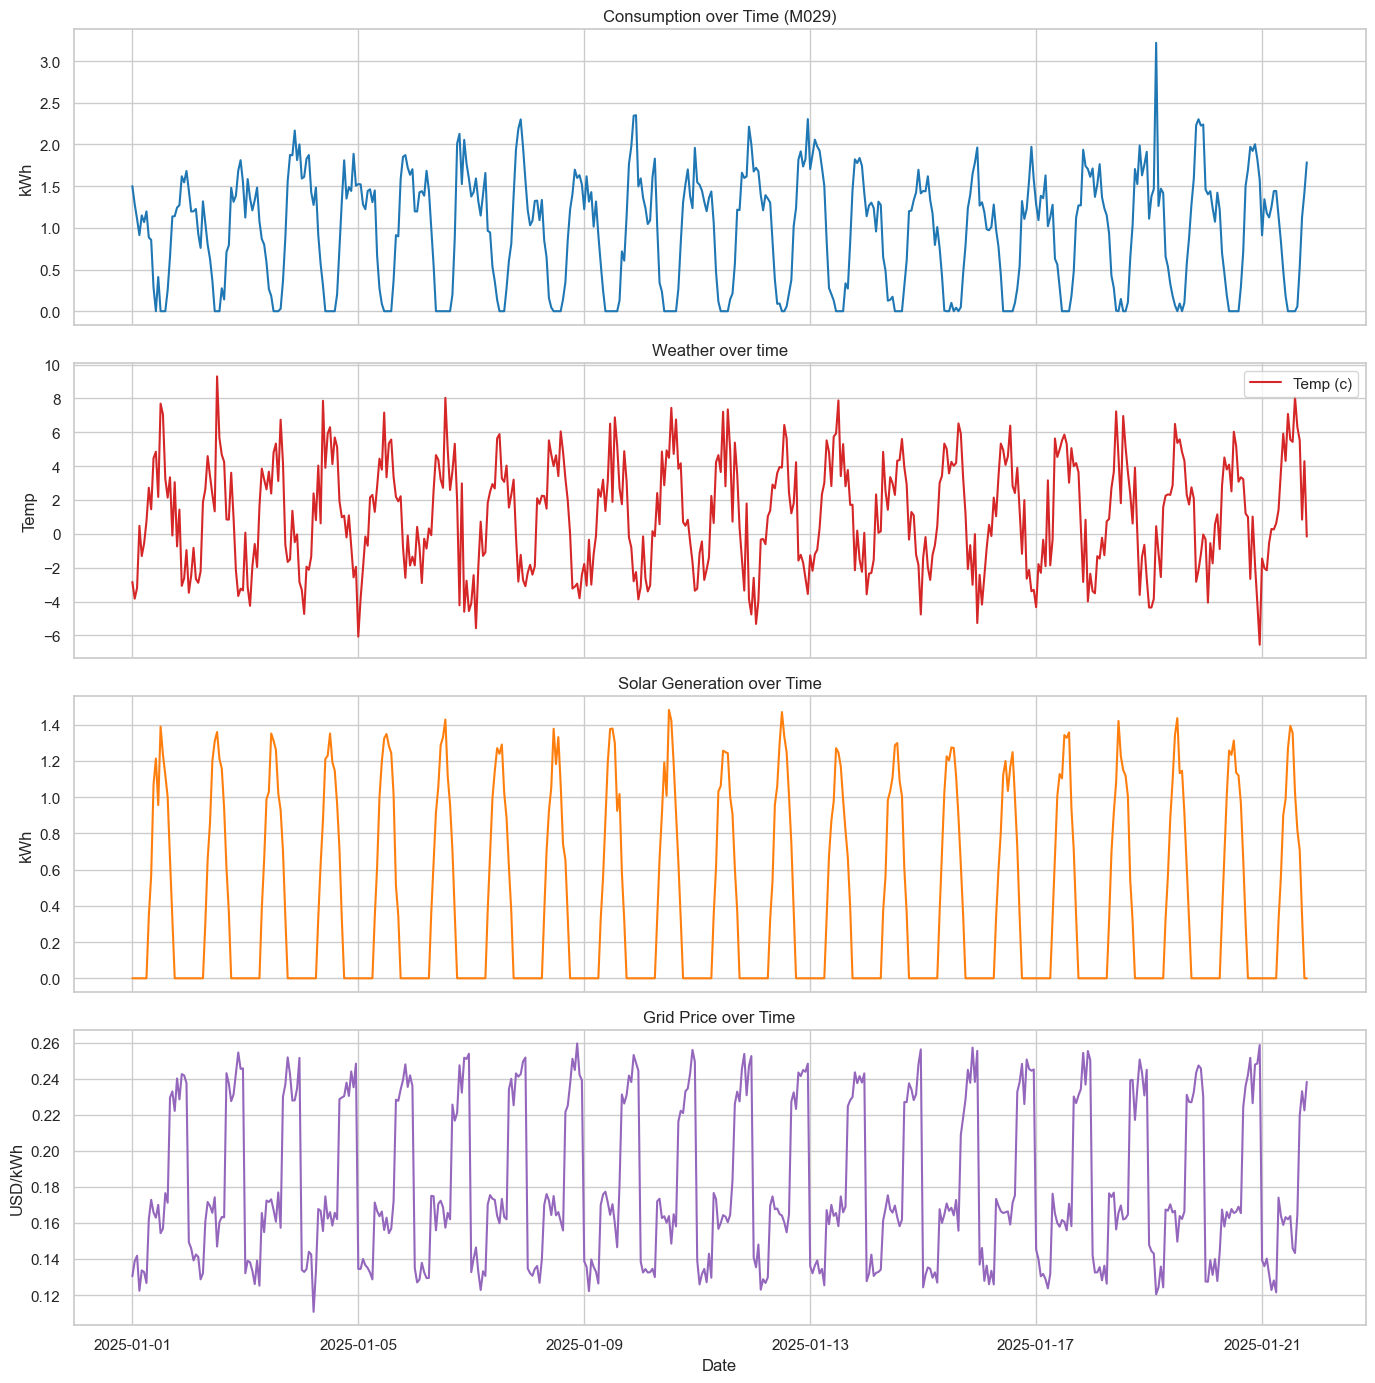

In [35]:
# 7) Visualize multiple statistical views for the selected residential meter
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Filter data for the selected meter_id
selected_meter_df = (
    merged_dataset.reset_index()
    .loc[lambda d: d["meter_id"] == selected_meter_id]
    .sort_values("date")
    .copy()
)

print(f"Plotting meter_id: {selected_meter_id}")
print(f"Rows after filtering: {len(selected_meter_df)}")

# A) Time-series view
# Consumption over time
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
sns.lineplot(data=selected_meter_df, x="date", y="consumption_kwh", ax=axes[0], color="tab:blue")
axes[0].set_title(f"Consumption over Time ({selected_meter_id})")
axes[0].set_ylabel("kWh")

# Weather over time
sns.lineplot(data=selected_meter_df, x="date", y="temp_c", ax=axes[1], color="tab:red", label="Temp (c)")
axes[1].set_title("Weather over time")
axes[1].set_ylabel("Temp")

# Solar generation over time
sns.lineplot(data=selected_meter_df, x="date", y="solar_generation_kwh", ax=axes[2], color="tab:orange")
axes[2].set_title("Solar Generation over Time")
axes[2].set_ylabel("kWh")

# Grid price over time
sns.lineplot(data=selected_meter_df, x="date", y="grid_price_usd_per_kwh", ax=axes[3], color="tab:purple")
axes[3].set_title("Grid Price over Time")
axes[3].set_ylabel("USD/kWh")
axes[3].set_xlabel("Date")
plt.tight_layout()
plt.show()



## Figure Description: Distribution, Behavior Effects, and Relationships

Use this as a presentation script:

- The histogram summarizes the overall spread of consumption values, including where observations are concentrated and whether the distribution is skewed.
- The weekend/holiday boxplot compares median use and variability across behavior groups, helping us evaluate lifestyle effects.
- The two regression plots test directional relationships between consumption and key predictors: temperature and solar generation.
- If points are widely dispersed, the relationship is weaker; if they align around the trend line, the predictor is more informative.
- The key message is that behavior and weather both contribute to demand, but their strengths can differ.

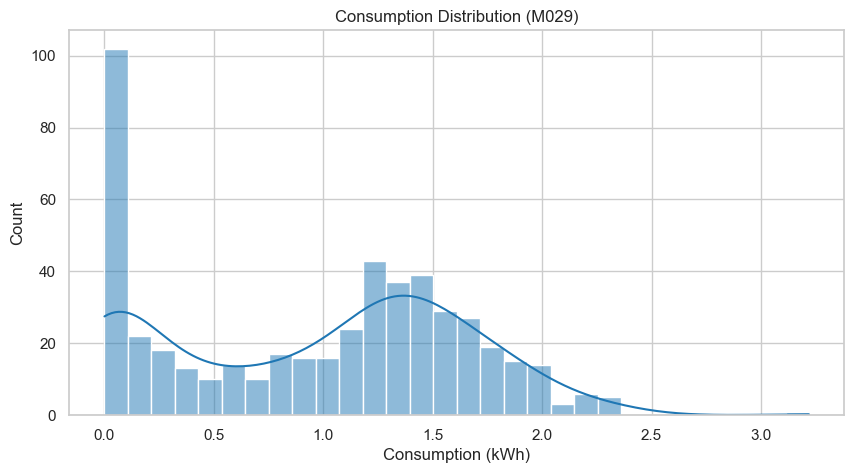

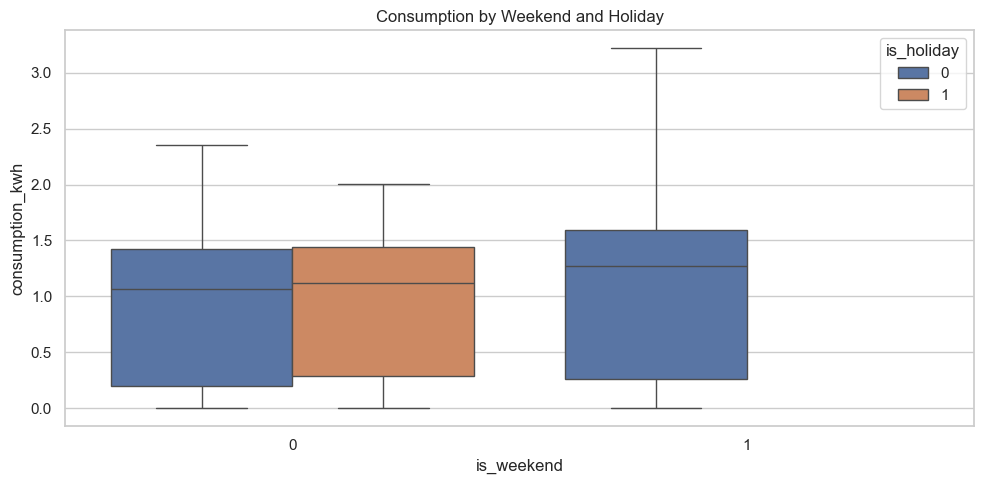

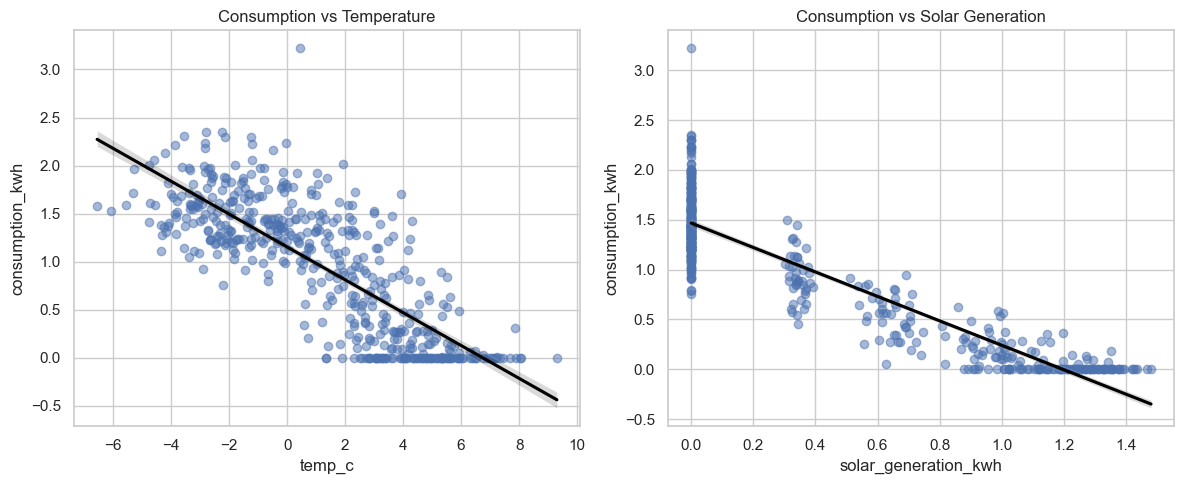

In [ ]:
# 7) 

# B) Distribution view
plt.figure(figsize=(10, 5))
sns.histplot(selected_meter_df["consumption_kwh"], bins=30, kde=True, color="tab:blue")
plt.title(f"Consumption Distribution ({selected_meter_id})")
plt.xlabel("Consumption (kWh)")
plt.ylabel("Count")
plt.show()

# C) Boxplots by behavior flags weekend and holiday consumption
plt.figure(figsize=(10, 5))
sns.boxplot(data=selected_meter_df, x="is_weekend", y="consumption_kwh", hue="is_holiday")
plt.title("Consumption by Weekend and Holiday")
plt.xlabel("is_weekend")
plt.ylabel("consumption_kwh")
plt.legend(title="is_holiday")
plt.tight_layout()
plt.show()

# D) Relationship view
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
sns.regplot(data=selected_meter_df, x="temp_c", y="consumption_kwh", scatter_kws={"alpha": 0.5}, line_kws={"color": "black"}, ax=ax1)
ax1.set_title("Consumption vs Temperature")

ax2 = plt.subplot(1, 2, 2)
sns.regplot(data=selected_meter_df, x="solar_generation_kwh", y="consumption_kwh", scatter_kws={"alpha": 0.5}, line_kws={"color": "black"}, ax=ax2)
ax2.set_title("Consumption vs Solar Generation")
plt.tight_layout()
plt.show()



## Figure Description: Seasonal Decomposition and Stationarity Check

Use this as a presentation script:

- This decomposition separates the daily consumption signal into trend, seasonal pattern, and residual noise.
- The trend component captures the long-term movement, while the seasonal component shows repeating behavior.
- The residual panel represents what remains after removing trend and seasonality, ideally closer to random noise.
- We support this visual interpretation with two diagnostics: seasonal strength and the ADF p-value for stationarity.
- The key message is whether we need stationarization before forecasting: if nonstationary, we should transform the series before modeling.

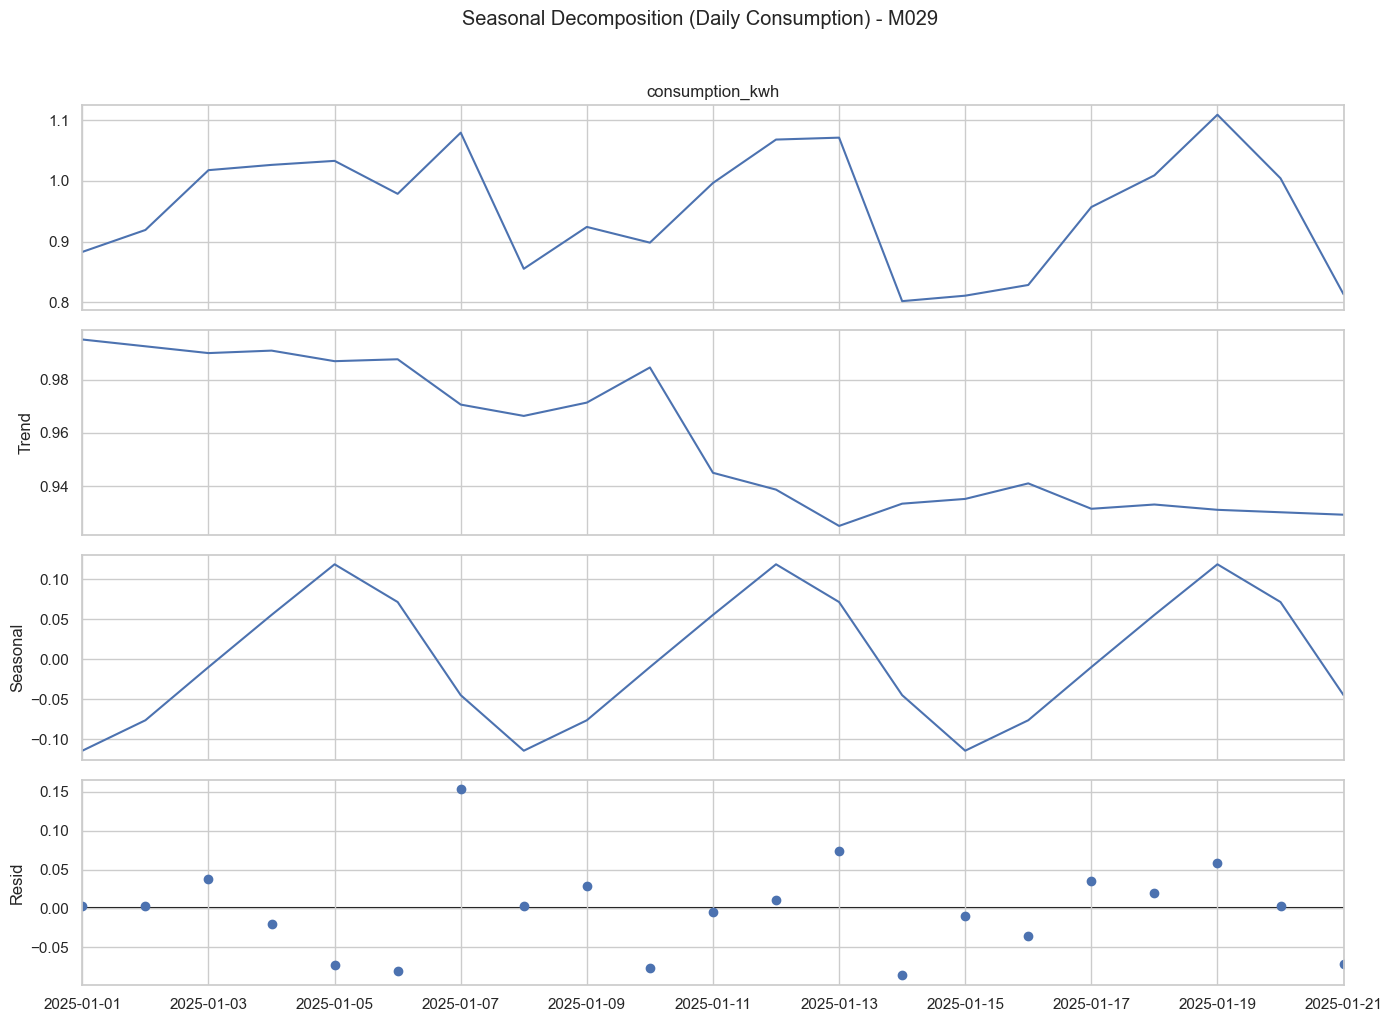

Seasonal strength (std ratio): 0.831
ADF p-value: 0.2972
Periodic component present: Yes
Nonstationary series: Yes


In [38]:
# Decompose the main component if there are periodic and nonstationary.
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Build a daily average series for decomposition
main_daily = (
    selected_meter_df.assign(day=selected_meter_df["date"].dt.floor("D"))
    .groupby("day")["consumption_kwh"]
    .mean()
    .sort_index()
)

# Use weekly period for daily data
period = 7
decomp = seasonal_decompose(main_daily, model="additive", period=period, extrapolate_trend="freq")

fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle(f"Seasonal Decomposition (Daily Consumption) - {selected_meter_id}", y=1.02)
plt.tight_layout()
plt.show()

# Simple diagnostics
seasonal_strength = decomp.seasonal.std() / main_daily.std()
adf_pvalue = adfuller(main_daily.dropna())[1]

print(f"Seasonal strength (std ratio): {seasonal_strength:.3f}")
print(f"ADF p-value: {adf_pvalue:.4f}")
print(f"Periodic component present: {'Yes' if seasonal_strength > 0.10 else 'No/weak'}")
print(f"Nonstationary series: {'Yes' if adf_pvalue > 0.05 else 'No'}")

## Figure Description: Daily Average Consumption with Weekend and Holiday Highlighting

Use this as a presentation script:

- This plot aggregates hourly values into daily average consumption to make behavioral patterns easier to see.
- Orange bands mark weekends, and red bands mark holidays, so we can visually compare special days against normal weekdays.
- The blue line tracks daily demand changes and helps identify whether these calendar effects are systematic.
- If peaks repeatedly overlap with weekend or holiday zones, it suggests user behavior has a measurable impact on energy use.
- The key message is that calendar context improves interpretation of consumption dynamics beyond weather alone.

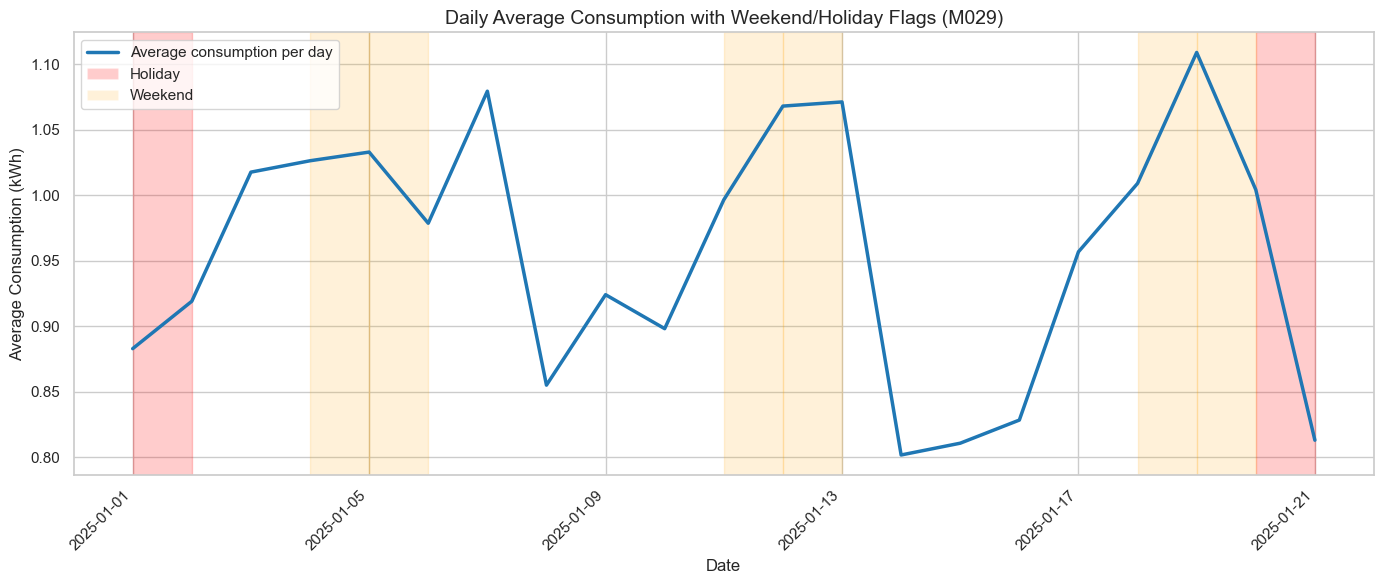

,day,avg_consumption_kwh,is_weekend,is_holiday
0,2025-01-01,0.882988,0,1
1,2025-01-02,0.919121,0,0
2,2025-01-03,1.017583,0,0
3,2025-01-04,1.026258,1,0
4,2025-01-05,1.032871,1,0


In [ ]:
# TODO: Check if we want to use this 

# Daily average consumption + weekend/holiday markers for the selected meter
daily_avg = (
    selected_meter_df.assign(day=selected_meter_df["date"].dt.floor("D"))
    .groupby("day", as_index=False)
    .agg(
        avg_consumption_kwh=("consumption_kwh", "mean"),
        is_weekend=("is_weekend", "max"),
        is_holiday=("is_holiday", "max"),
    )
    .sort_values("day")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Add fill_between for holiday regions (red)
for idx, row in daily_avg.iterrows():
    if row["is_holiday"]:
        ax.axvspan(
            row["day"],
            row["day"] + pd.Timedelta(days=1),
            alpha=0.2,
            color="red",
        )

# Add fill_between for weekend regions (orange)
for idx, row in daily_avg.iterrows():
    if row["is_weekend"]:
        ax.axvspan(
            row["day"],
            row["day"] + pd.Timedelta(days=1),
            alpha=0.15,
            color="orange",
        )

# Add lineplot
sns.lineplot(
    data=daily_avg,
    x="day",
    y="avg_consumption_kwh",
    color="tab:blue",
    linewidth=2.5,
    label="Average consumption per day",
    ax=ax,
)

plt.title(f"Daily Average Consumption with Weekend/Holiday Flags ({selected_meter_id})", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Consumption (kWh)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add custom legend for shading
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="red", alpha=0.2, label="Holiday"))
handles.append(Patch(facecolor="orange", alpha=0.15, label="Weekend"))
ax.legend(handles=handles, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

daily_avg.head()